# COVID Parcel Business Analysis - Final Project
## Group 7
### Team Members:
- **Abeez Maredia**
- **Urvish Nayak**
- **Ayman Karovadiya**

### Project Overview:
This project analyzes the impact of COVID-19 on a parcel delivery business. We examine 
delivery volumes, revenue trends, regional performance, and operational efficiency 
during the pandemic period. Our goal is to provide executive-level insights and 
actionable recommendations.

### Date: April 2026

# 1. Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Loading Data

In [2]:
df = pd.read_csv("COVID_Parcel_Business.csv")

# 3. Standarizing Column Names

In [3]:
cols = [c.lower() for c in df.columns]
df.columns = cols

col_map = {
    'customer': next((c for c in cols if 'customer' in c), None),
    'year': next((c for c in cols if 'year' in c), None),
    'week': next((c for c in cols if 'week' in c), None),
    'parcel': next((c for c in cols if 'parcel' in c or 'volume' in c), None)
}

cust_col = col_map['customer']
year_col = col_map['year']
week_col = col_map['week']
parcel_col = col_map['parcel']

print("Detected Columns:", col_map)

Detected Columns: {'customer': 'fakecustomerid', 'year': 'the_year', 'week': 'the_week', 'parcel': 'volume'}


# 4. Basic Information

In [4]:
print(df.head())
print(df.describe())

   fakecustomerid  the_year  the_week  volume
0          718117      2021         1       8
1          718117      2020         7     257
2          718117      2019        39     141
3          718117      2018         1      14
4          718117      2021         2     192
       fakecustomerid       the_year       the_week         volume
count   190719.000000  190719.000000  190719.000000  190719.000000
mean    541440.234963    2019.395220      25.676377    1174.911519
std     264861.365663       1.068845      14.722539   11586.730666
min     100771.000000    2018.000000       1.000000       1.000000
25%     308930.000000    2018.000000      13.000000      25.000000
50%     529707.000000    2019.000000      25.000000      58.000000
75%     778800.000000    2020.000000      38.000000     162.000000
max     999362.000000    2021.000000      53.000000  640590.000000


# 5. weekly trend analysis

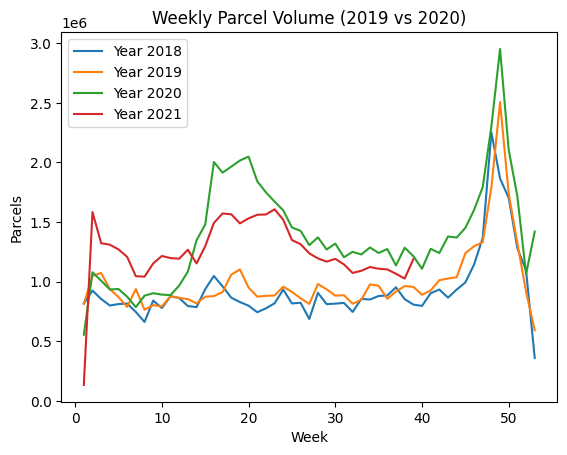

In [5]:
weekly = df.groupby([year_col, week_col])[parcel_col].sum().reset_index()

plt.figure()
for year in weekly[year_col].unique():
    temp = weekly[weekly[year_col] == year]
    plt.plot(temp[week_col], temp[parcel_col], label=f"Year {year}")

plt.legend()
plt.title("Weekly Parcel Volume (2019 vs 2020)")
plt.xlabel("Week")
plt.ylabel("Parcels")
plt.show()

# 6. pre-covid vs covid split

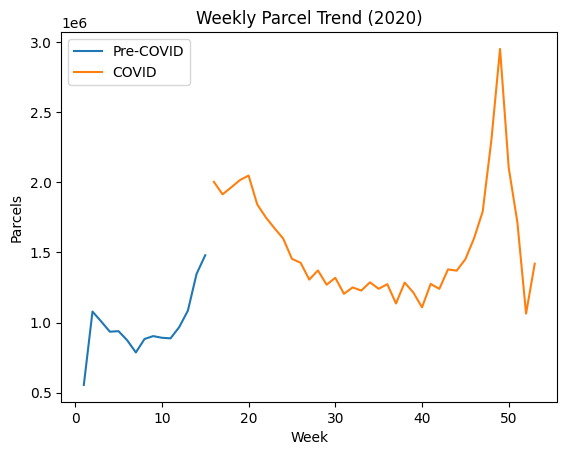

In [6]:
pre_covid_2020 = df[(df[year_col] == 2020) & (df[week_col] <= 15)]
covid_2020 = df[(df[year_col] == 2020) & (df[week_col] > 15)]

weekly_pre = pre_covid_2020.groupby(week_col)[parcel_col].sum()
weekly_covid = covid_2020.groupby(week_col)[parcel_col].sum()

plt.figure()
plt.plot(weekly_pre.index, weekly_pre.values, label='Pre-COVID')
plt.plot(weekly_covid.index, weekly_covid.values, label='COVID')

plt.legend()
plt.title("Weekly Parcel Trend (2020)")
plt.xlabel("Week")
plt.ylabel("Parcels")
plt.show()

# 7. ISGR calculation

In [7]:
pre_covid_2020 = df[(df[year_col] == 2020) & (df[week_col] <= 15)]
covid_2020 = df[(df[year_col] == 2020) & (df[week_col] > 15)]

pre_2019 = df[(df[year_col] == 2019) & (df[week_col] <= 15)]


vol_2020 = pre_covid_2020[parcel_col].sum()
vol_2019 = pre_2019[parcel_col].sum()

isgr = ((vol_2020 - vol_2019) / vol_2019) * 100
print("Industry Standard Growth Rate (ISGR):", round(isgr,2), "%")

Industry Standard Growth Rate (ISGR): 11.4 %


# 8. customer level analysis

In [8]:
baseline = pre_2019.groupby(cust_col)[parcel_col].sum()
covid = covid_2020.groupby(cust_col)[parcel_col].sum()

final_df = pd.DataFrame({
    'Vol_Baseline': baseline,
    'Vol_COVID': covid
}).fillna(0)

final_df['Growth_Rate'] = np.where(
    final_df['Vol_Baseline'] == 0,
    np.nan,
    (final_df['Vol_COVID'] - final_df['Vol_Baseline']) / final_df['Vol_Baseline'] * 100
)

print(final_df.head())

                Vol_Baseline  Vol_COVID  Growth_Rate
fakecustomerid                                      
100771                 442.0     1341.0   203.393665
102180                1365.0     3989.0   192.234432
102643                 745.0     1104.0    48.187919
102750                 344.0      209.0   -39.244186
103308               19560.0    79952.0   308.752556
